This notebook includes initial results on preliminary dataset exploration (to be used in project proposal).  
Plots included in this notebook: a donor bar plot, a cell-type bar plot, a donor x cell-type heatmap, and UMAP colored by patient ID and cell type. 

In [ ]:
import scanpy as sc
import anndata as ad
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import pertpy as pt
adata = pt.data.stephenson_2021_subsampled()

# adata = ad.read_h5ad("../data/stephenson_2021_subsampled.h5ad") # for local loads, if pertpy does not work

In [13]:
# focus on healthy samples only
adata_ctrl = adata[adata.obs["disease"] == "normal"].copy()
print("Control cells:", adata_ctrl.n_obs)
print("Control donors:", adata_ctrl.obs["patient_id"].nunique())

Control cells: 14426
Control donors: 29


In [ ]:
# check the distribution of donors and cell types in the control samples
donor_col = "patient_id"
celltype_col = "cell_type"
print(adata_ctrl.obs[donor_col].value_counts().head())
print(adata_ctrl.obs[celltype_col].value_counts().head())

patient_id
CV0902    1000
CV0904     500
CV0911     500
CV0915     500
CV0917     500
Name: count, dtype: int64
cell_type
CD16-positive, CD56-dim natural killer cell, human      2117
naive thymus-derived CD4-positive, alpha-beta T cell    1838
naive B cell                                            1326
CD14-positive monocyte                                  1183
central memory CD4-positive, alpha-beta T cell          1182
Name: count, dtype: int64


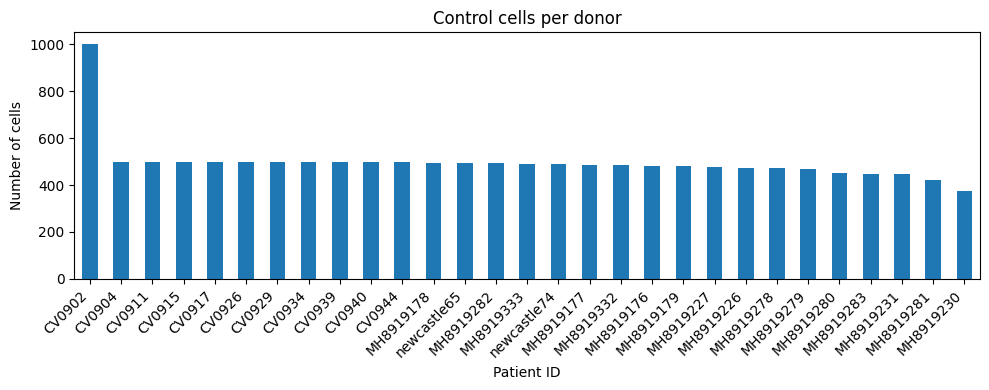

In [ ]:
plt.figure(figsize=(10, 4))
adata_ctrl.obs[donor_col].value_counts().sort_values(ascending=False).plot(kind="bar")
plt.title("Control cells per donor")
plt.xlabel("Patient ID")
plt.ylabel("Number of cells")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

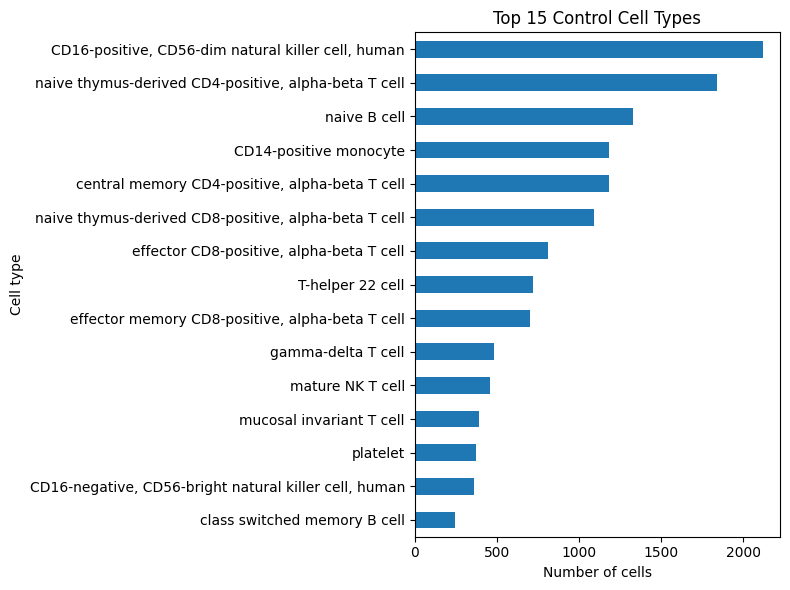

In [ ]:
# get counts
counts = adata_ctrl.obs[celltype_col].value_counts()

# keep top 15
top_counts = counts.head(15)

plt.figure(figsize=(8, 6))
top_counts.sort_values().plot(kind="barh")

plt.title("Top 15 Control Cell Types")
plt.xlabel("Number of cells")
plt.ylabel("Cell type")

plt.tight_layout()
plt.show()

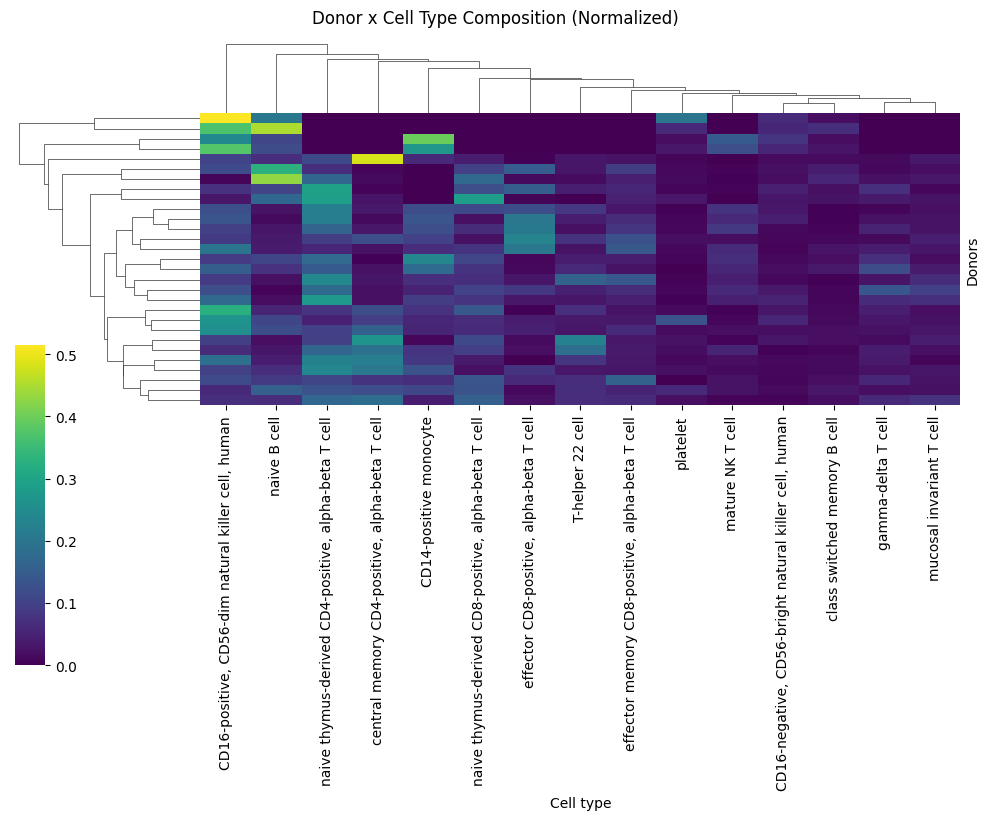

In [34]:
# crosstab
ct = pd.crosstab(
    adata_ctrl.obs[donor_col],
    adata_ctrl.obs[celltype_col]
)

# keep top 15 cell types globally
top_celltypes = ct.sum(axis=0).sort_values(ascending=False).head(15).index
ct = ct[top_celltypes]

# normalize per donor (row-wise proportions)
ct_norm = ct.div(ct.sum(axis=1), axis=0)

# clustered heatmap
g = sns.clustermap(
    ct_norm,
    cmap="viridis",
    figsize=(10, 8),
    metric="euclidean",
    method="average",
    yticklabels=False,
    cbar_pos=(0.02, 0.2, 0.03, 0.4)
)

g.ax_heatmap.set_xlabel("Cell type")
g.ax_heatmap.set_ylabel("Donors")

plt.suptitle("Donor x Cell Type Composition (Normalized)", y=1.02)
plt.show()

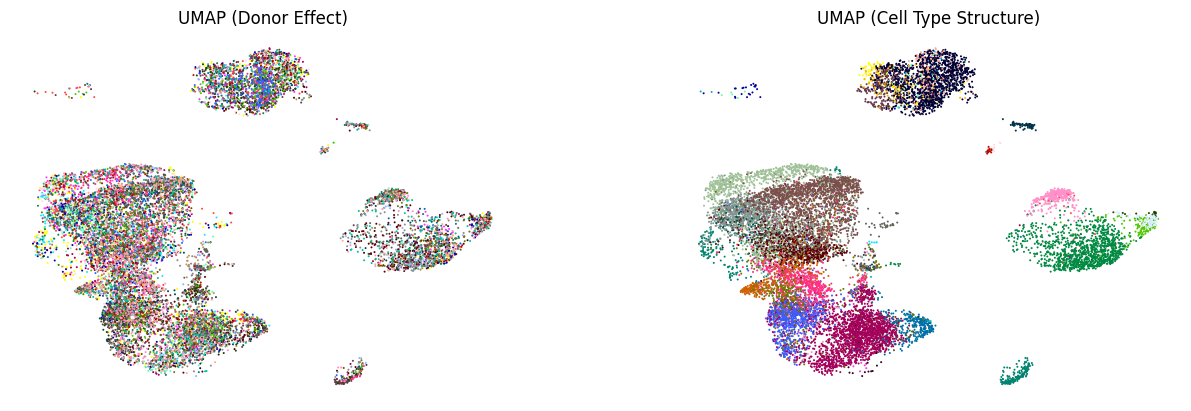

In [32]:
sc.pl.umap(
    adata_ctrl,
    color=[donor_col, celltype_col],
    title=["UMAP (Donor Effect)", "UMAP (Cell Type Structure)"],
    frameon=False,
    wspace=0.2,
    legend_loc=None 
)